# Applying Transfer Learning with ResNet-18 (ResNet Model)

We built four custom CNNs from scratch using different architectures and techniques. Now, we will make a big jump into applying a straightforward yet powerful technique called Transfer Learning.

Instead of making the entire model ourselves, we will take a model trained on one task and reuse it as the starting point for a new, related task. The interesting part is that these pre-trained models can have substantially more layers and parameters, often containing millions or even billions of interconnected parameters. However, since Transfer Learning hides this complexity, we don't have to build or manage this structure. We start with the weights from the pre-trained model and then fine-tune them using our smaller dataset for our specific goal.

Transfer Learning works well in many cases because deep neural networks learn features hierarchically, moving from general to more specific concepts across their layers. So, instead of starting from random configurations, a model begins with highly optimized feature detectors already shaped by millions of previous examples. This saves time and computational resources by using pre-learned patterns instead of training a CNN from scratch.

This first Transfer Learning model will be based on ResNet-18, an 18-layer convolutional neural network designed specifically for image recognition and classification. This model will be referred to as the **ResNet Model** from now on

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform_transfer_train, get_transform_transfer_eval, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform_train = get_transform_transfer_train()
transform_eval = get_transform_transfer_eval()
dataset = get_data(transform_train)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomCrop(size=(200, 200), padding=None)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

In [5]:
train_data, val_data, test_data = get_datasets(transform_train, transform_eval)

In [6]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [7]:
from src.models import get_resnet18

In [8]:
resnet_model = get_resnet18()
resnet_model.load_state_dict(torch.load('models/05_resnet_aug_sgd_momentum50.pth'))

<All keys matched successfully>

In [9]:
resnet_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Evaluating Model

In [10]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [11]:
loss, accuracy, all_labels, all_predictions = evaluate_model(resnet_model, val_loader)

In [12]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 0.3771
Accuracy: 90.73%


Given the validation loss of 0.3771 and accuracy of 90.73%, we can see a very significant improvement in both validation metrics with the ResNet Model compared to any model so far. As mentioned before, the model becomes highly overparameterized and is trained on a substantially larger amount of data through pre-training, which gives it much more capacity to learn useful features. Even though the model may seem to overfit at first glance, the extra parameters give the model more room to learn complex patterns and relationships rather than making sharp, erratic predictions. This results in an impressive performance on unseen data.

### - Confusion Matrix

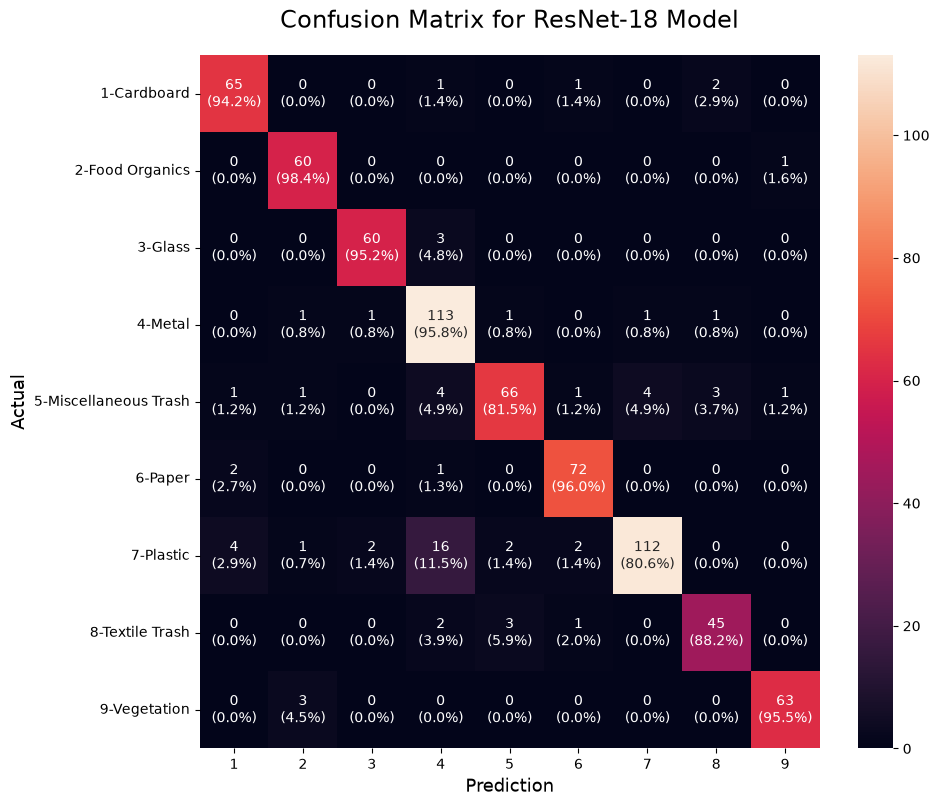

In [13]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for ResNet-18 Model")

**Confusion Matrix Insights:**

. Basically all classes achieved very high accuracies, with six of them getting over 95%.

. The only notable misclassification was Plastic being categorized as Metal 11.5% of the time.

. It is worth mentioning that, while the previous models tended to overclassify objects as Plastic, that does not seem to be the case anymore.

### - Inspecting misclassified images

Found 16 7-Plastic → 4-Metal


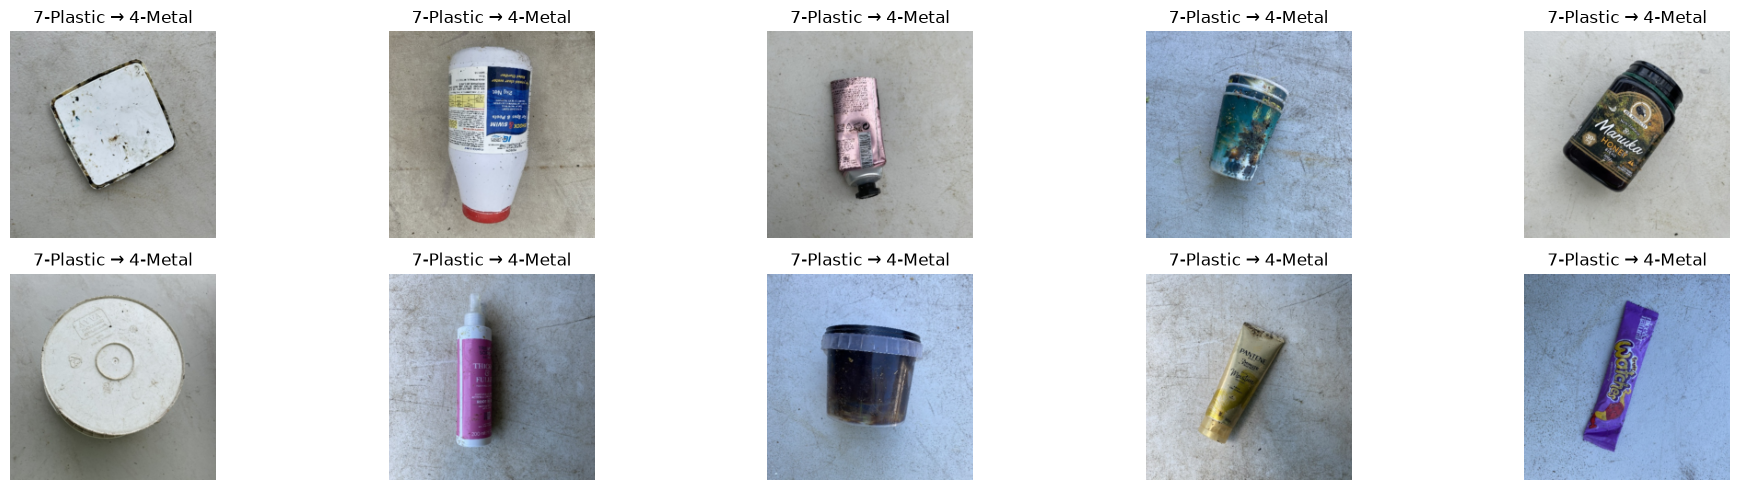

In [14]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "7-Plastic", "4-Metal", 
                  mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # 16 errors